#Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.




## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.


## 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.


## 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

The notebook is designed so that students can upload/place the CSV in the same folder as this notebook.


In [50]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# VS Code / local-machine dataset path
# Keep the CSV in the same folder as this notebook.
DATA_FILE = "C:/Users/Atharva/Desktop/AICTE VOIS Internship/Major project/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv("C:/Users/Atharva/Desktop/AICTE VOIS Internship/Major project/seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully.
Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 4. Initial Data Understanding

In [52]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 4000
Number of columns: 28


In [53]:
# Top 5 rows

df.head(5)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [54]:
# Bottom 5 rows

df.tail(5)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [55]:
# Random sample of records

df.sample(5, random_state=42)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [56]:
# Column names

print(df.columns.tolist())


['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [57]:
# Data types and non-null counts

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [58]:
# Numerical summary statistics

df.describe()


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [59]:
# Categorical summary

df.describe(include="object")


,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 5. Data Quality Analysis

Before performing analysis, investigate missing values, duplicates, data types and unusual values.

**Student task:** Explain what you observe and justify each cleaning decision.


In [60]:
# Missing values

missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]


,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


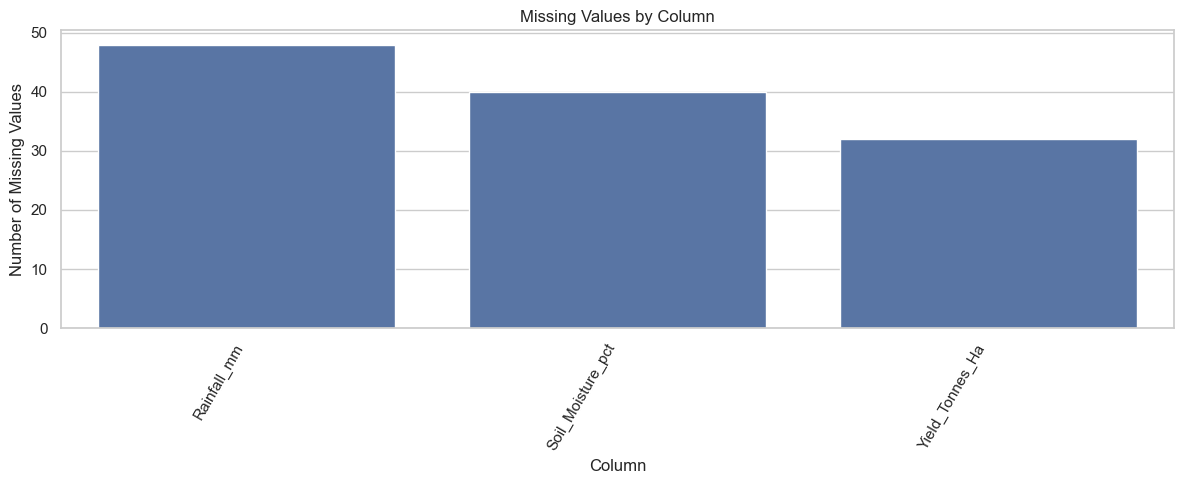

In [61]:
# Visualize missing values

plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


In [62]:
# Duplicate records

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [63]:
# Remove duplicate rows

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (4000, 28)


In [64]:
# Check data types again

df.dtypes


Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [65]:
# Check unique values for categorical columns

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])



Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [66]:
# Check missing values after duplicate removal

df.isnull().sum().sort_values(ascending=False).head(10)


Rainfall_mm           48
Soil_Moisture_pct     40
Yield_Tonnes_Ha       32
Farm_ID                0
Crop                   0
District               0
Farm_Area_Hectares     0
Season                 0
Avg_Temperature_C      0
Humidity_pct           0
dtype: int64

### Missing Value Treatment

Choose an appropriate strategy based on the nature of each variable.

Possible approaches:
- Remove records only when justified.
- Fill numerical values using an appropriate statistic when appropriate.
- Fill categorical values using a suitable category or method.
- Clearly document why the chosen approach is reasonable.

Do not blindly replace every missing value with zero.


In [67]:
# Treat missing values in numerical columns using median imputation.
# Median is used because it is less sensitive to extreme values than the mean.

numeric_columns = df.select_dtypes(include=np.number).columns

missing_before = df[numeric_columns].isnull().sum()
missing_before = missing_before[missing_before > 0]

print("Missing numerical values before treatment:")
print(missing_before)

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nRemaining missing values:", int(df.isnull().sum().sum()))


Missing numerical values before treatment:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Remaining missing values: 0


## 6. Feature / Variable Review

Review the available variables and classify them conceptually as:

- Identifier variables
- Categorical variables
- Numerical variables
- Environmental variables
- Operational variables
- Production/performance variables
- Economic variables

**Student task:** Explain which variables are most relevant to the seasonal-performance problem and why.


In [68]:
# Numerical and categorical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)


Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


## 7. Statistical Analysis

Perform descriptive statistical analysis to understand the distribution and variation of the data.

Students should interpret the statistics rather than simply displaying them.


In [69]:
# Descriptive statistics

stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats


,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [70]:
# Median and standard deviation

statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary


,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [71]:
# Seasonal descriptive summary

season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])
season_summary


Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

## 8. Univariate Analysis

Univariate analysis examines one variable at a time.

Create and interpret suitable plots for:
- Important categorical variables
- Important numerical variables
- Seasonal distribution
- Production/performance distributions
- Economic distributions

The examples below are starting points. Students should add or modify plots based on their own analytical questions.


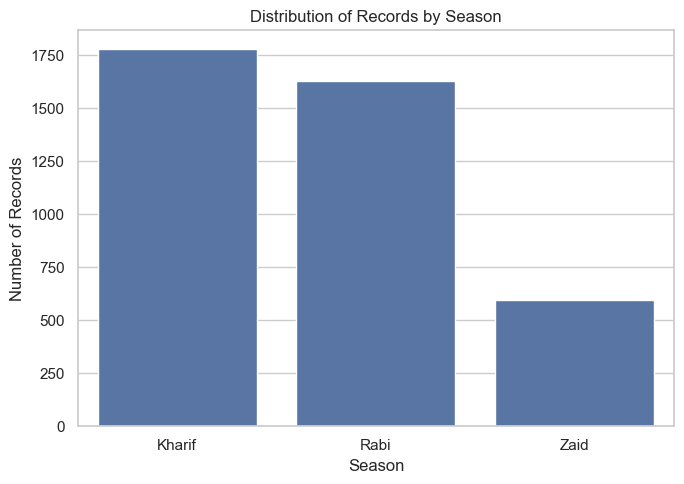

In [72]:
# Univariate: Season distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


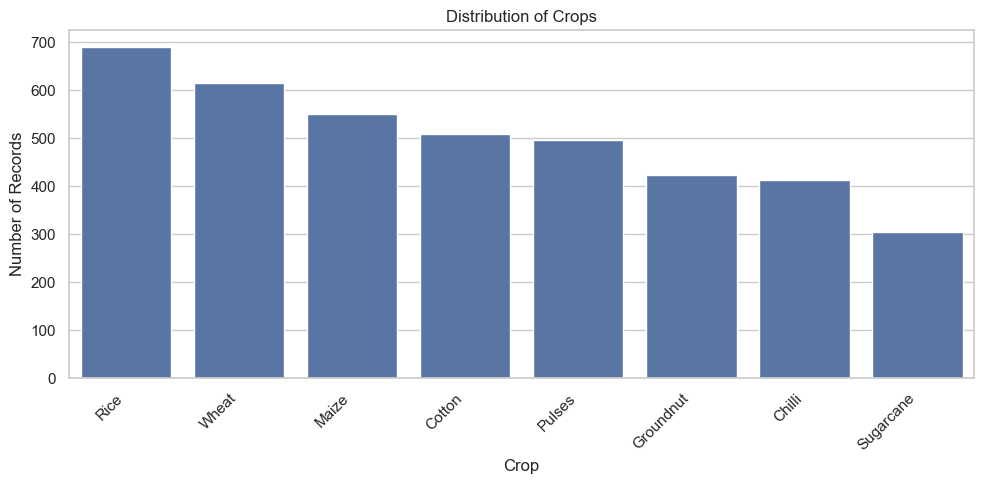

In [73]:
# Univariate: Crop distribution

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


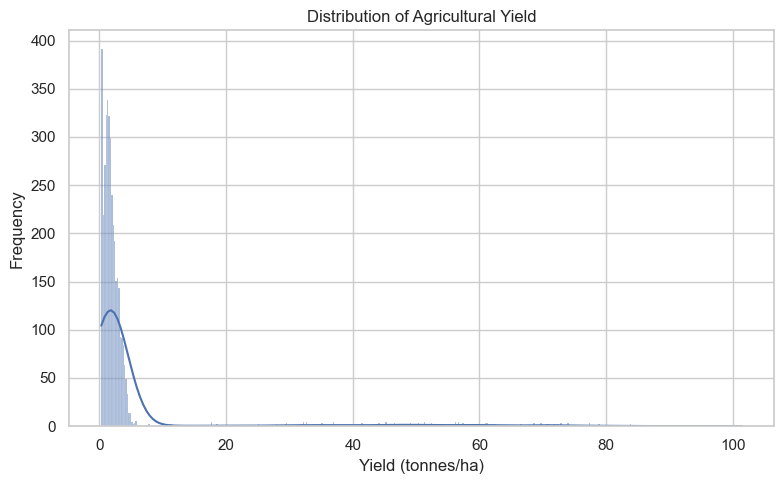

In [74]:
# Univariate: Yield distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


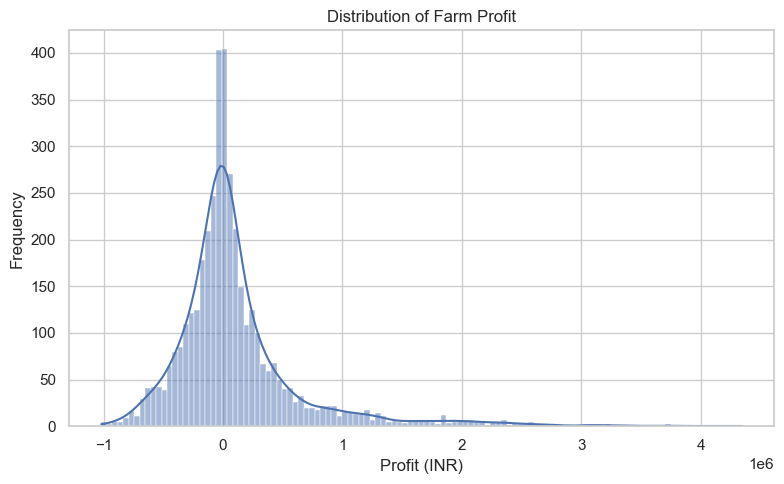

In [75]:
# Univariate: Profit distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


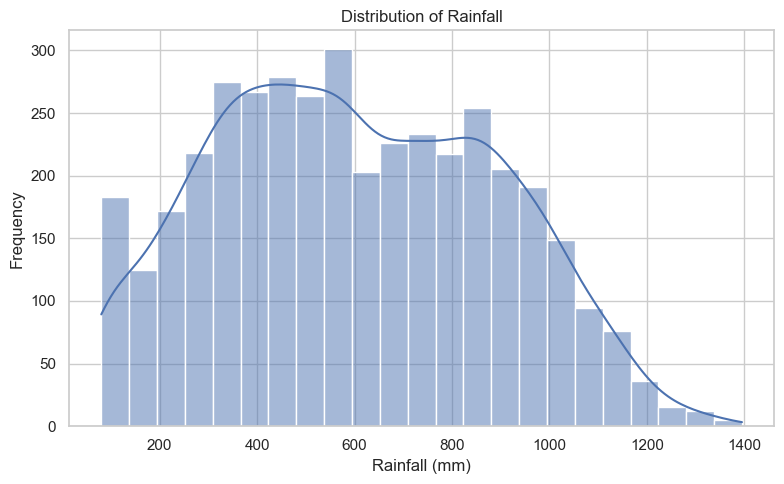

In [76]:
# Univariate: Rainfall distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


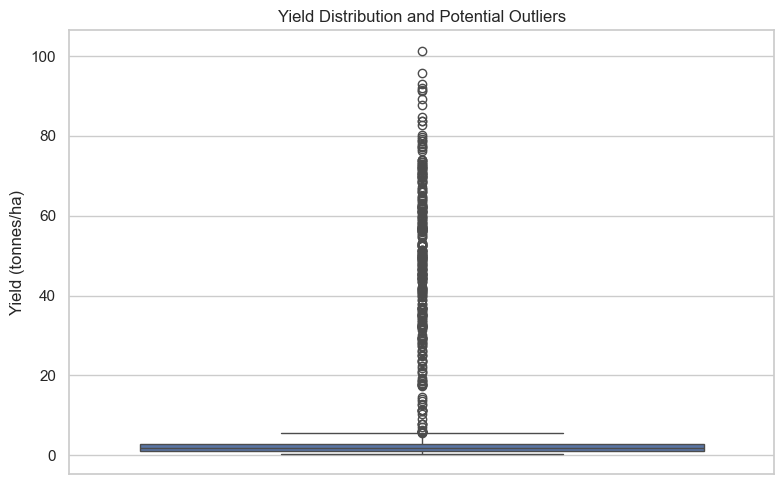

In [77]:
# Univariate: Boxplot for yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


## 9. Outlier Analysis

Investigate potential outliers using statistical and visual methods.

**Student task:** Do not automatically delete outliers. Decide whether an extreme value is:
- A data-entry problem,
- A legitimate observation,
- Or something requiring further investigation.


### Univariate: Season distribution (Pie Chart)

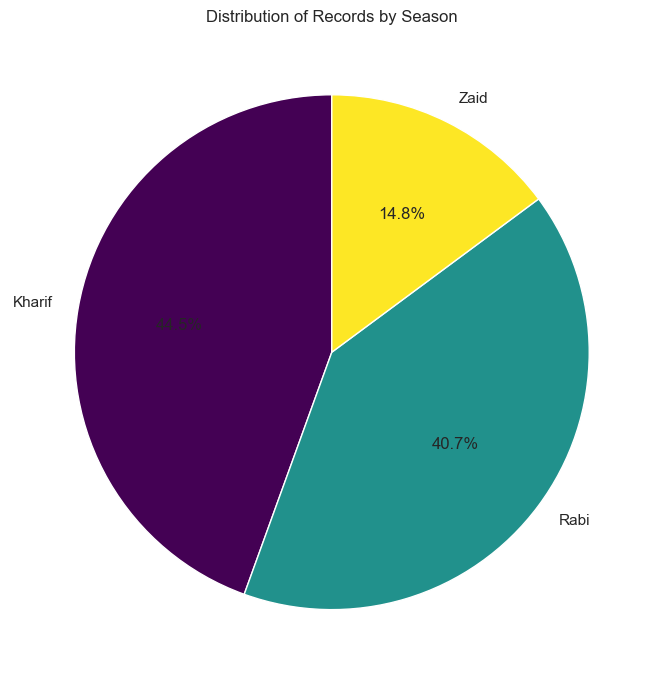

In [78]:
plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('') # Hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()

In [79]:
# IQR-based outlier summary for numerical columns

outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

outlier_summary


,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


## 10. Bivariate Analysis

Bivariate analysis examines relationships or differences between two variables.

Students should investigate relationships that are relevant to the seasonal agriculture problem.


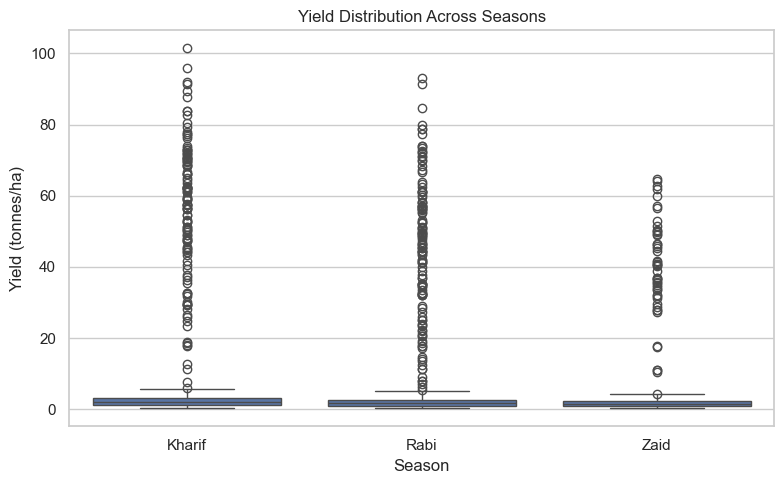

In [80]:
# Bivariate: Season vs Yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


### Bar plots for Bivariate Analysis

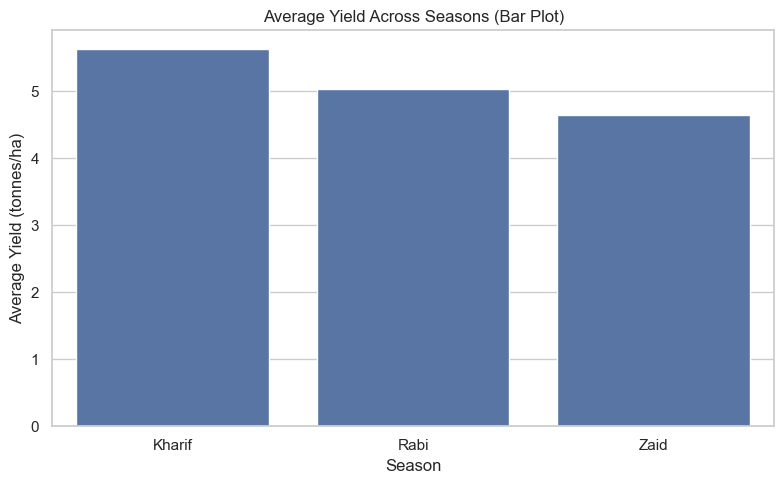

In [81]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

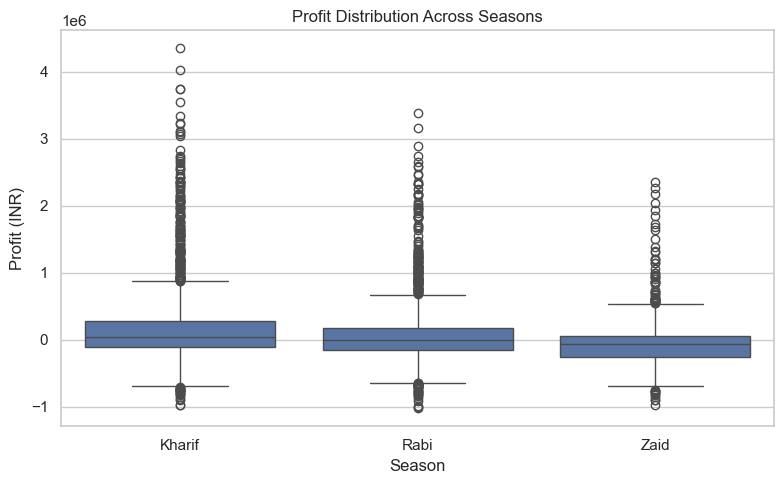

In [82]:
# Bivariate: Season vs Profit

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()


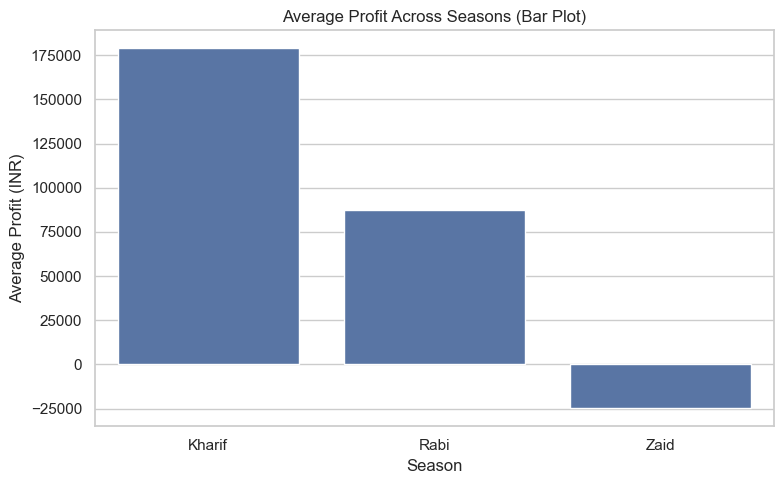

In [83]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

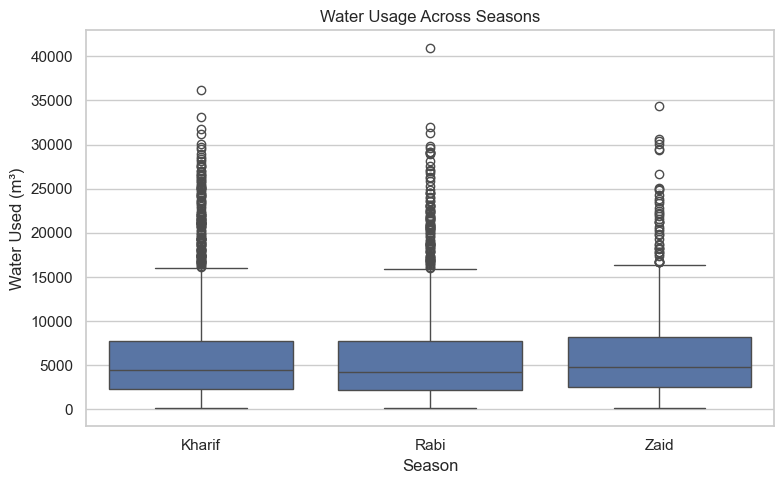

In [84]:
# Bivariate: Season vs Water Usage

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.tight_layout()
plt.show()


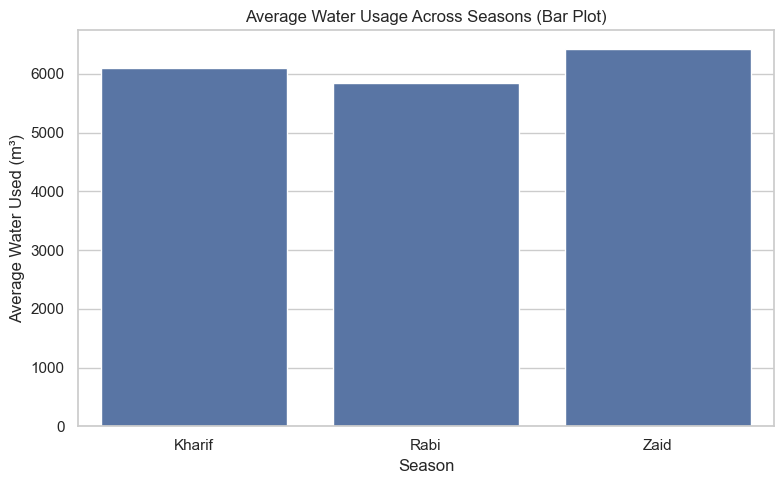

In [85]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Water_Used_m3", errorbar=None)
plt.title("Average Water Usage Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.tight_layout()
plt.show()

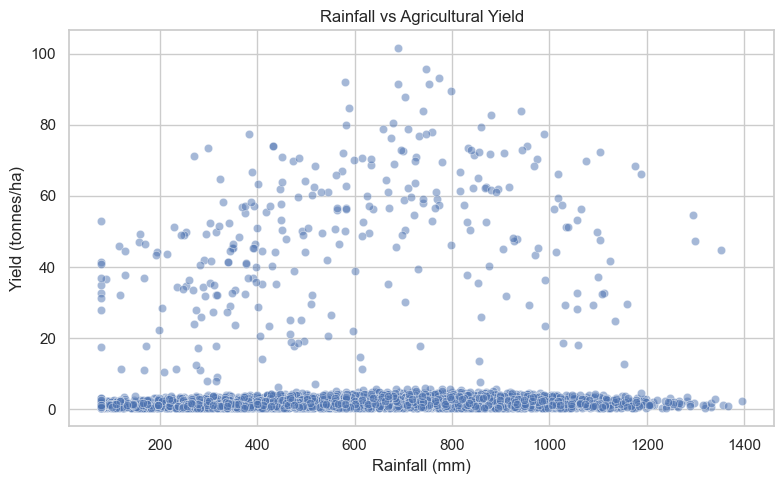

In [86]:
# Bivariate: Rainfall vs Yield

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


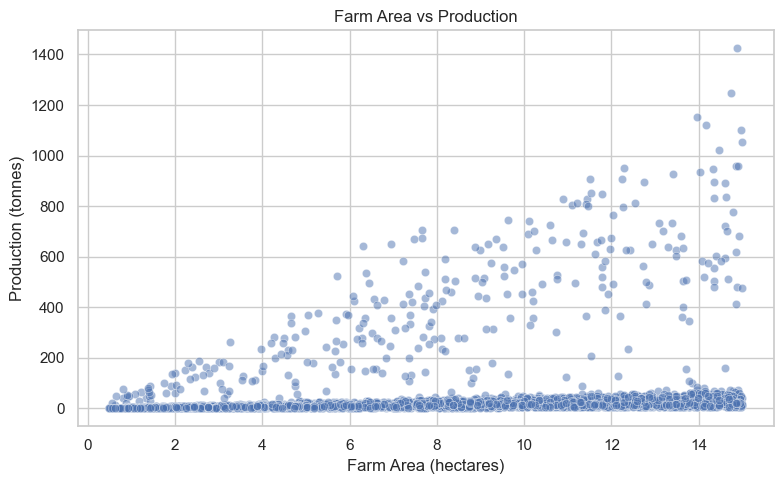

In [87]:
# Bivariate: Farm area vs Production

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()


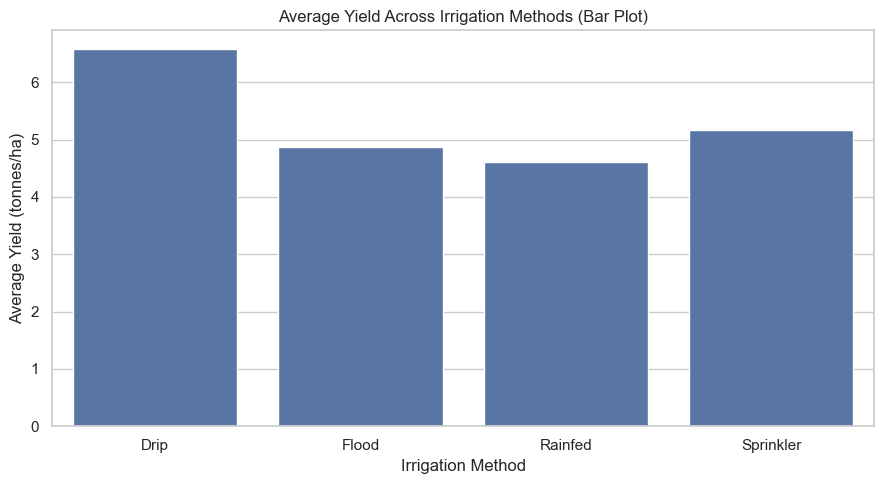

In [88]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Irrigation Methods (Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

## 11. Multivariate Analysis

Multivariate analysis examines more than two variables together.

Use multivariate plots to investigate how season interacts with other dimensions such as crop, region, environmental conditions, resource usage or economic performance.


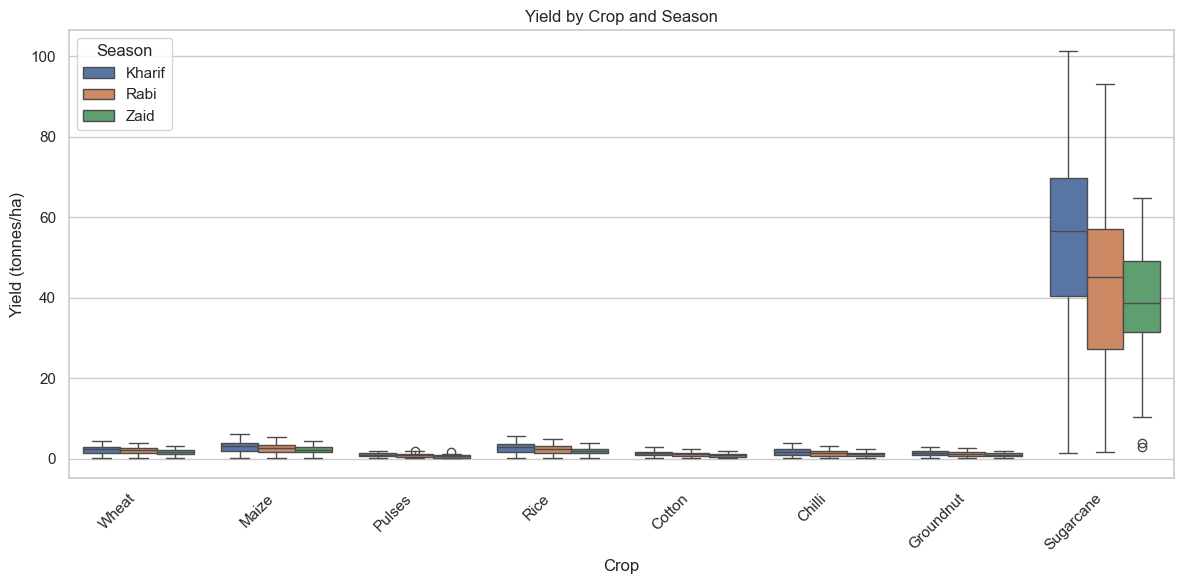

In [89]:
# Multivariate: Season, crop and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


### Multivariate: Grouped Bar Plot of Average Yield by Crop and Season

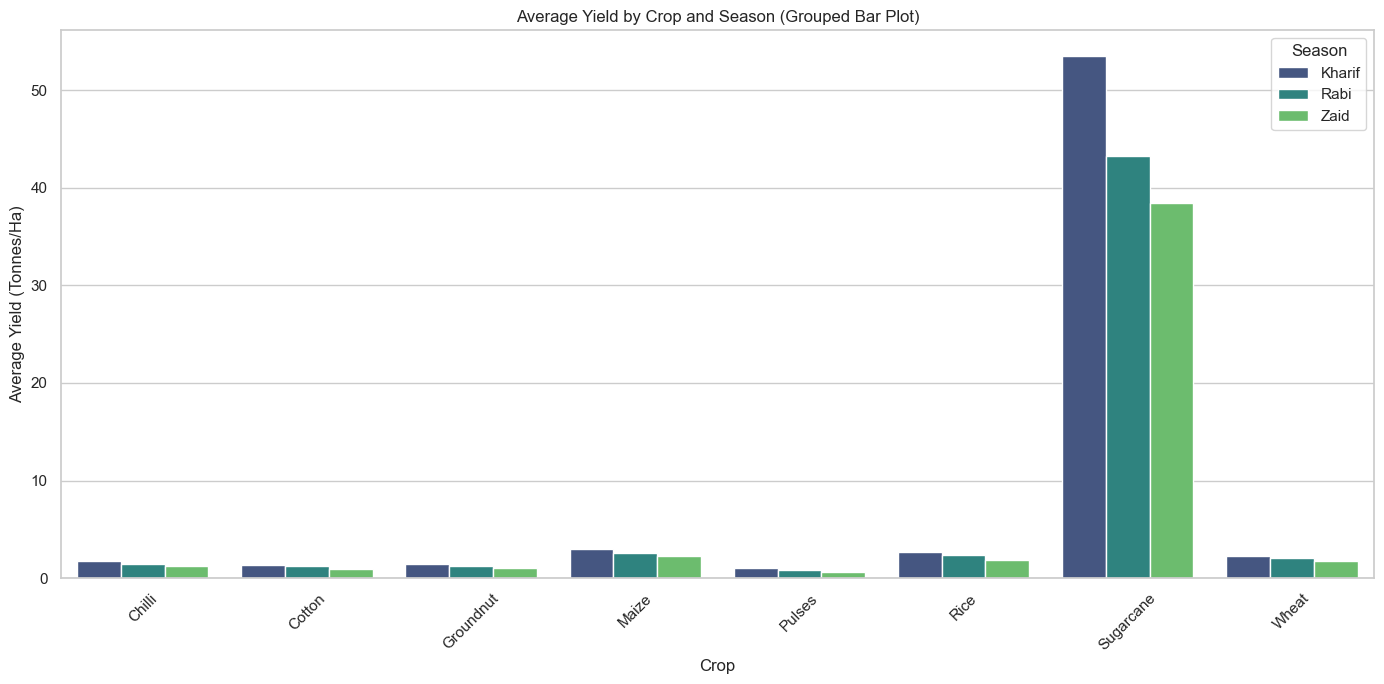

In [90]:
# Create crop-season summary
crop_season_summary = (
    df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"]
    .mean()
    .reset_index()
    .rename(columns={"Yield_Tonnes_Ha": "Average_Yield"})
)

# Plot average yield by crop and season
plt.figure(figsize=(14, 7))

sns.barplot(
    data=crop_season_summary,
    x="Crop",
    y="Average_Yield",
    hue="Season",
    palette="viridis"
)

plt.title("Average Yield by Crop and Season (Grouped Bar Plot)")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

### Multivariate: Pair Plot of Key Environmental and Performance Metrics by Season

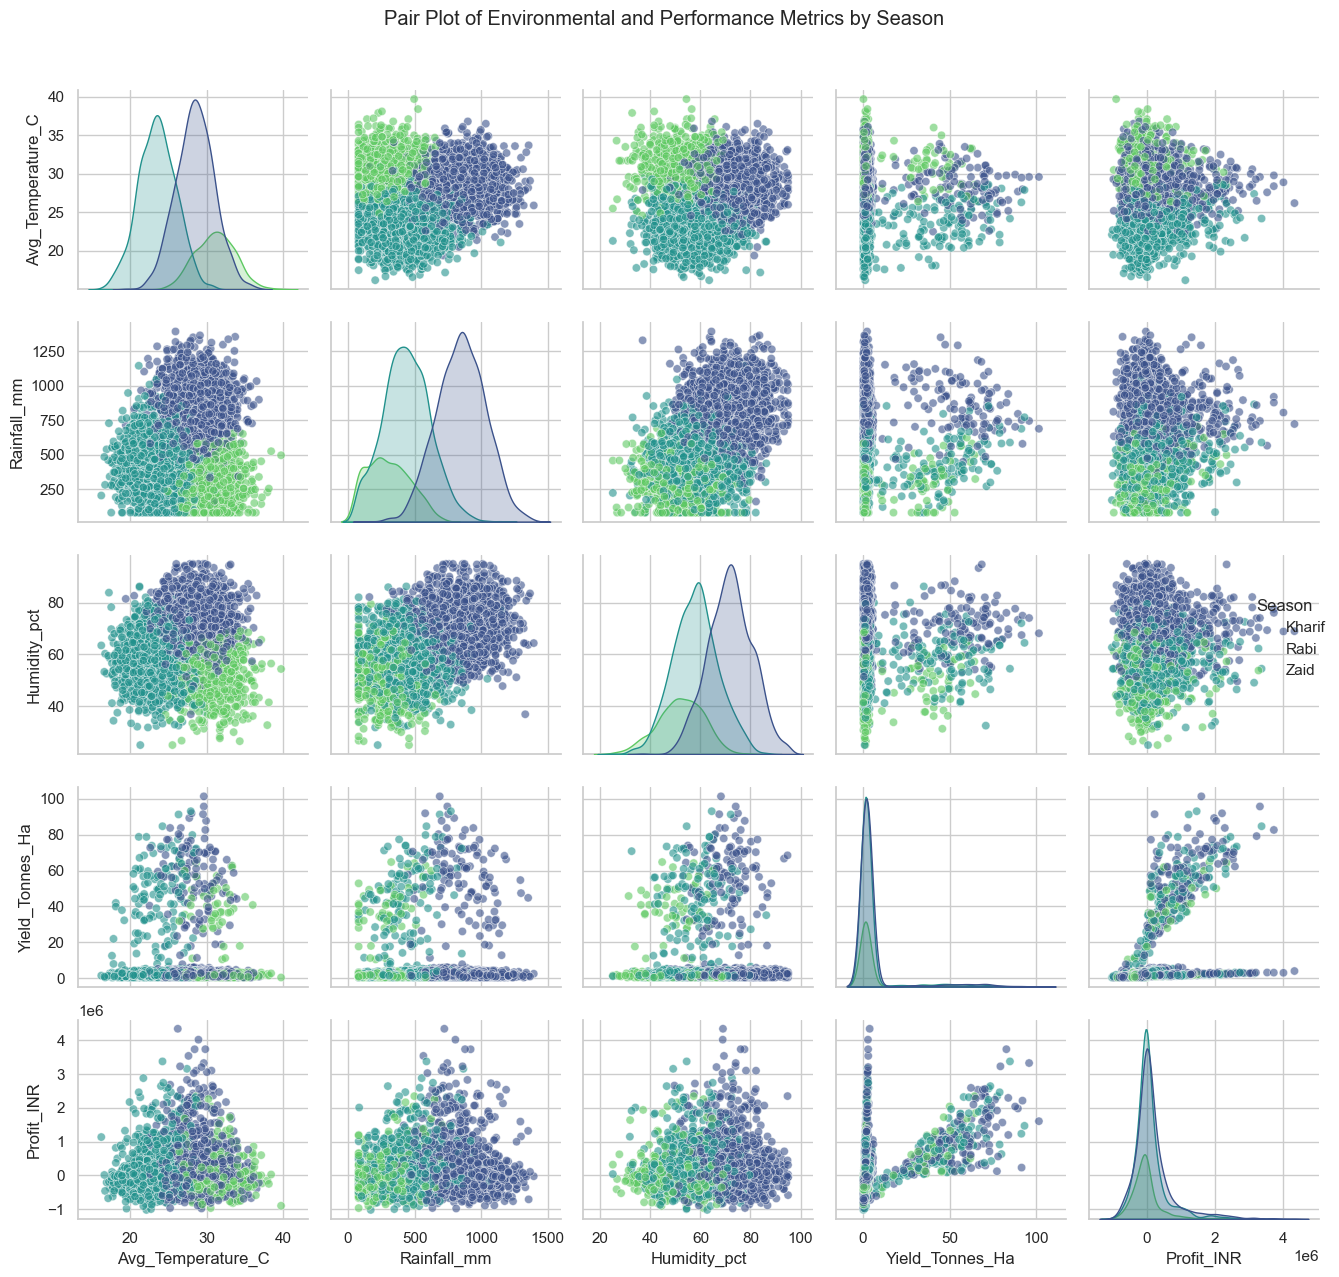

In [91]:
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

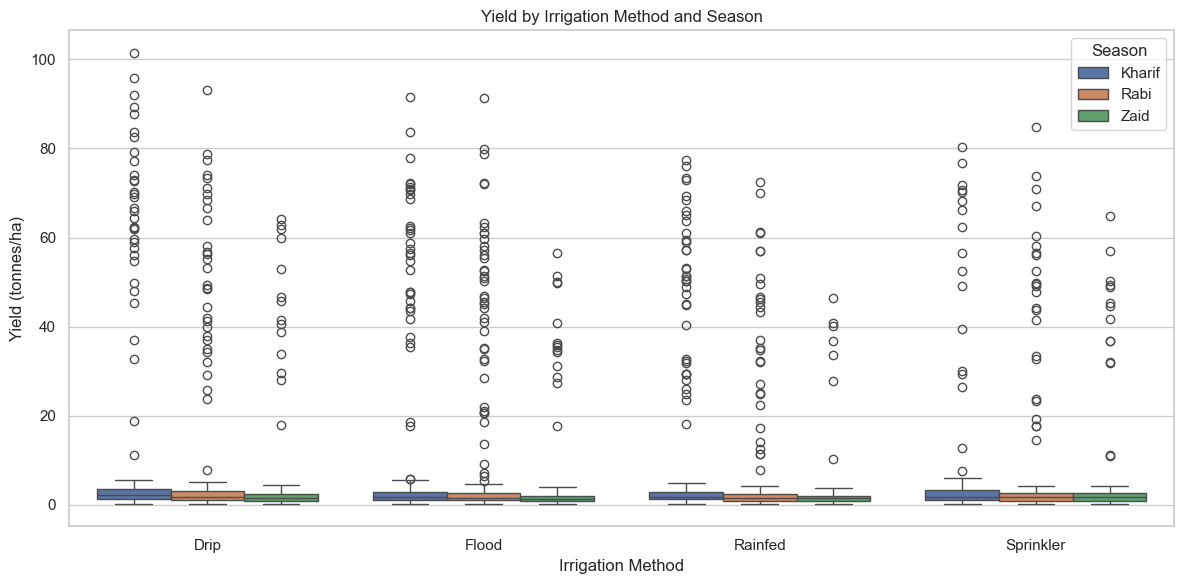

In [92]:
# Multivariate: Season, irrigation and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


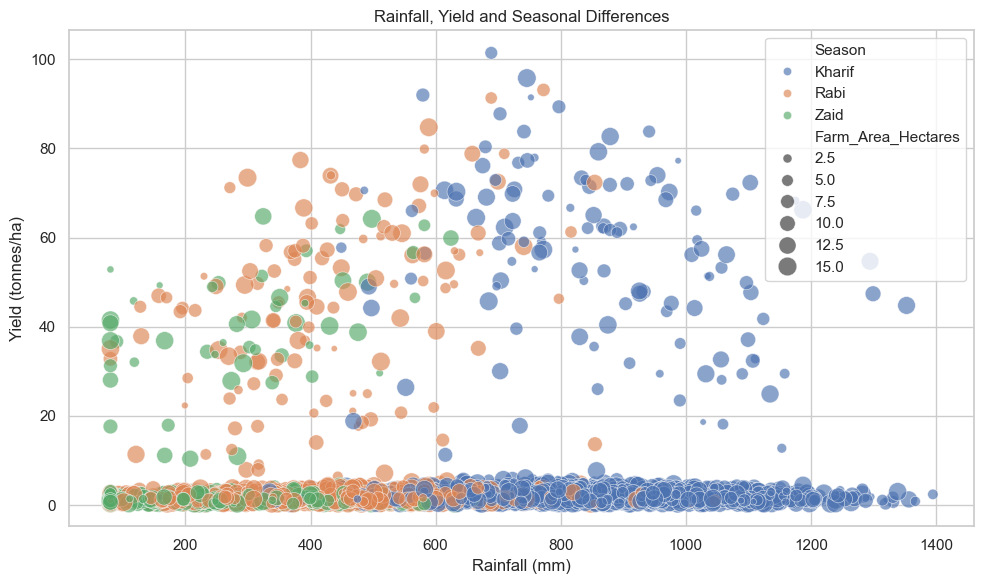

In [93]:
# Multivariate: Rainfall, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


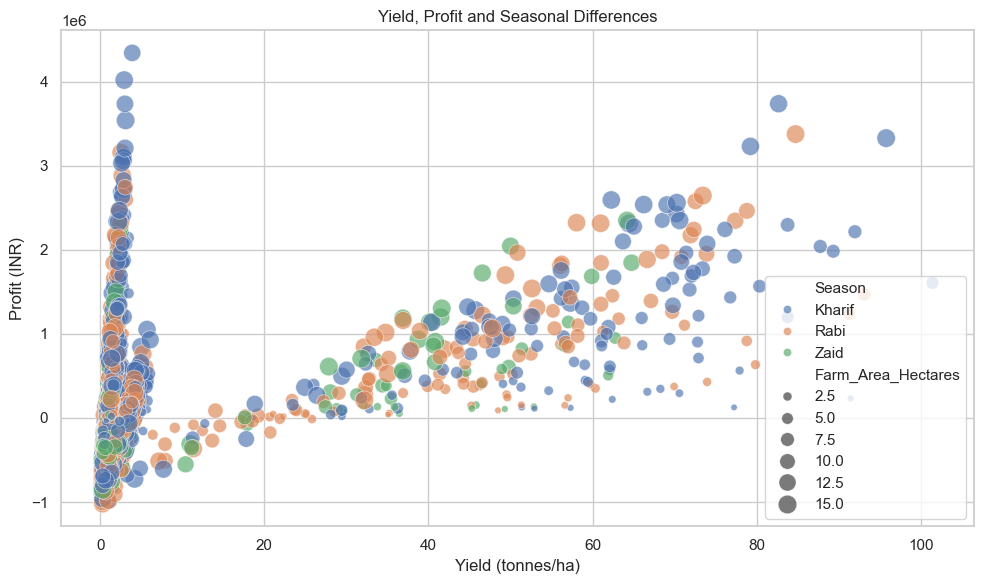

In [94]:
# Multivariate: Profit, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()


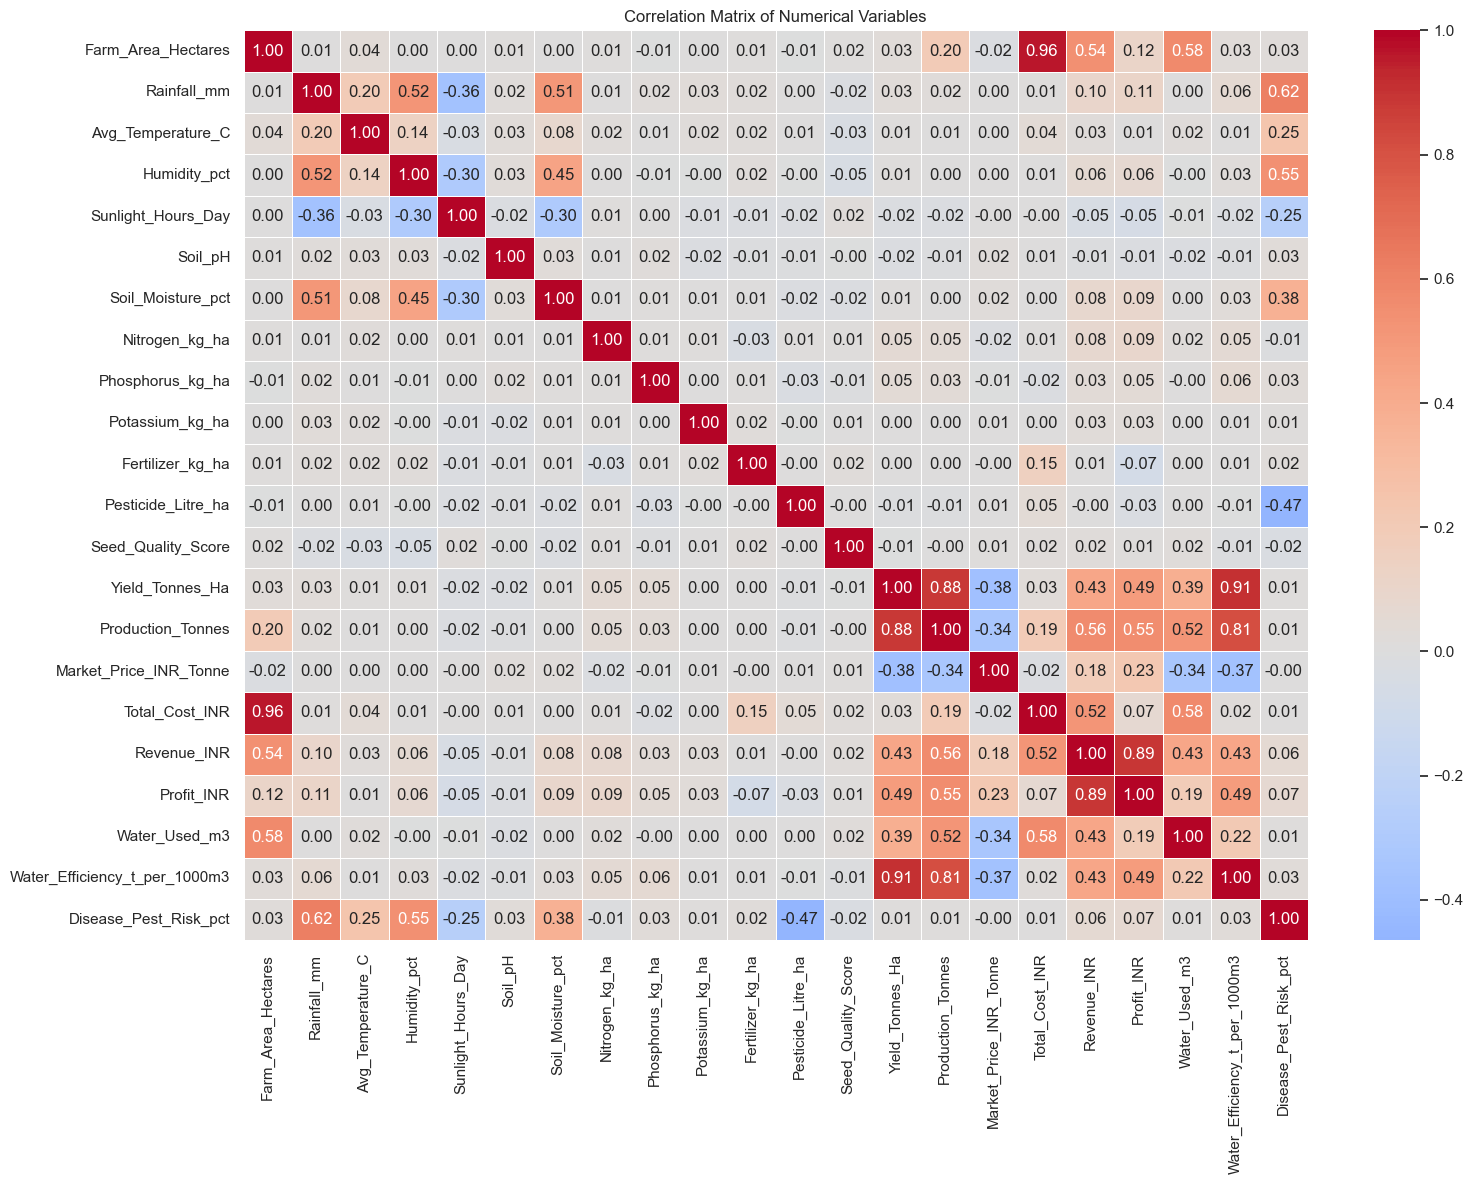

In [95]:
# Correlation heatmap for numerical variables

plt.figure(figsize=(16, 12))
corr = df[numeric_columns].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


## 12. Seasonal Comparison

Students should now move from individual plots to structured comparisons.

### Student task
Create suitable summary tables and visualizations to compare seasons across meaningful measures.

Do not assume that every variable needs to be compared. Select variables that help answer the project problem.


In [96]:
# General seasonal summary

season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics


,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89"


In [97]:
# Compare crop performance within each season

crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(
          Average_Yield=("Yield_Tonnes_Ha", "mean"),
          Average_Profit=("Profit_INR", "mean"),
          Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .round(2)
      .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

crop_season_summary


Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

## 13. Statistical Significance Testing

Descriptive statistics and visualizations show seasonal differences, but statistical testing helps determine whether the observed differences are statistically significant.

The one-way ANOVA test is used here to compare the mean yield and mean profit across the three seasons. A p-value below 0.05 is treated as statistically significant.


In [98]:
# One-way ANOVA: Yield across seasons and Profit across seasons
from scipy.stats import f_oneway

season_groups = {
    season: group
    for season, group in df.groupby("Season")
}

yield_groups = [
    group["Yield_Tonnes_Ha"].dropna()
    for group in season_groups.values()
]

profit_groups = [
    group["Profit_INR"].dropna()
    for group in season_groups.values()
]

yield_anova = f_oneway(*yield_groups)
profit_anova = f_oneway(*profit_groups)

print("ANOVA: Yield across seasons")
print(f"F-statistic = {yield_anova.statistic:.4f}")
print(f"p-value     = {yield_anova.pvalue:.6f}")

if yield_anova.pvalue < 0.05:
    print("Result: Mean yield differs significantly across seasons at the 5% significance level.")
else:
    print("Result: No statistically significant difference in mean yield across seasons at the 5% significance level.")

print("\nANOVA: Profit across seasons")
print(f"F-statistic = {profit_anova.statistic:.4f}")
print(f"p-value     = {profit_anova.pvalue:.6e}")

if profit_anova.pvalue < 0.05:
    print("Result: Mean profit differs significantly across seasons at the 5% significance level.")
else:
    print("Result: No statistically significant difference in mean profit across seasons at the 5% significance level.")


ANOVA: Yield across seasons
F-statistic = 1.5439
p-value     = 0.213678
Result: No statistically significant difference in mean yield across seasons at the 5% significance level.

ANOVA: Profit across seasons
F-statistic = 34.2918
p-value     = 1.712416e-15
Result: Mean profit differs significantly across seasons at the 5% significance level.


## 14. Additional Student-Driven Analysis

This section is intentionally open-ended.

Students should add **at least 3 additional analyses** that are not already provided above.

Possible directions include:
- Regional differences
- Crop-specific seasonal patterns
- Resource usage
- Economic performance
- Environmental conditions
- Risk patterns
- Relationships discovered during exploration

The student must explain why each additional analysis is relevant to the project problem.


,count,mean,median
Irrigation_Method,,,
Drip,915,6.58,1.94
Sprinkler,734,5.16,1.78
Flood,1310,4.86,1.66
Rainfed,1041,4.60,1.72


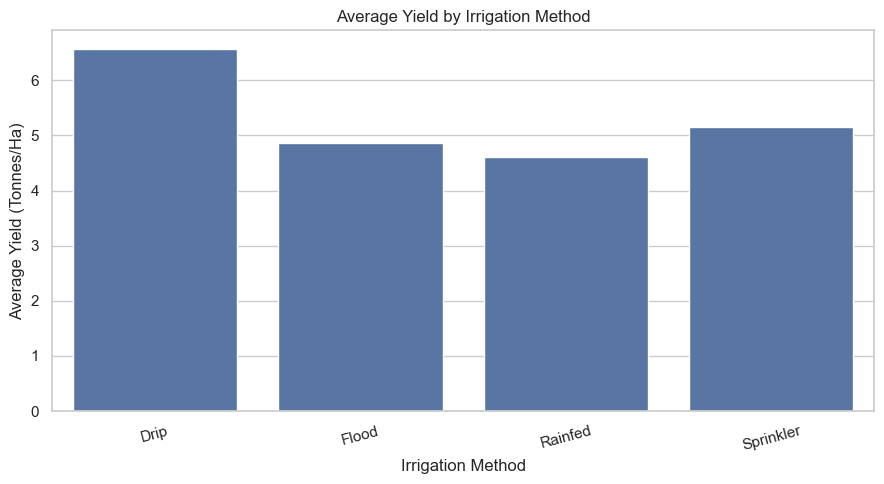

Interpretation: This comparison identifies whether yield levels are associated with different irrigation methods. It does not prove that irrigation method alone causes the observed yield differences.


In [99]:
# Student Analysis 1
# Question: Does average yield differ across irrigation methods?

irrigation_yield = (
    df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
      .round(2)
)

display(irrigation_yield)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    errorbar=None
)
plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Interpretation: This comparison identifies whether yield levels are associated with different irrigation methods. It does not prove that irrigation method alone causes the observed yield differences.")


,count,mean,median
Season,,,
Kharif,1779,54.47,54.50
Rabi,1627,40.48,40.60
Zaid,594,38.22,37.90


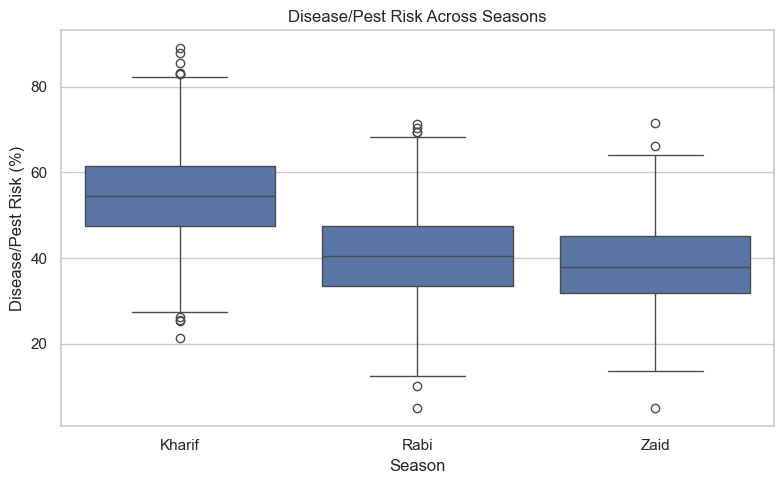

Interpretation: The seasonal comparison highlights which seasons have higher observed disease/pest risk and can help identify periods that may require closer monitoring.


In [100]:
# Student Analysis 2
# Question: How does disease/pest risk vary across seasons?

season_risk = (
    df.groupby("Season")["Disease_Pest_Risk_pct"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
      .round(2)
)

display(season_risk)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Disease_Pest_Risk_pct")
plt.title("Disease/Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Disease/Pest Risk (%)")
plt.tight_layout()
plt.show()

print("Interpretation: The seasonal comparison highlights which seasons have higher observed disease/pest risk and can help identify periods that may require closer monitoring.")


,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.46
14,Rabi,Sugarcane,43.29
22,Zaid,Sugarcane,38.42


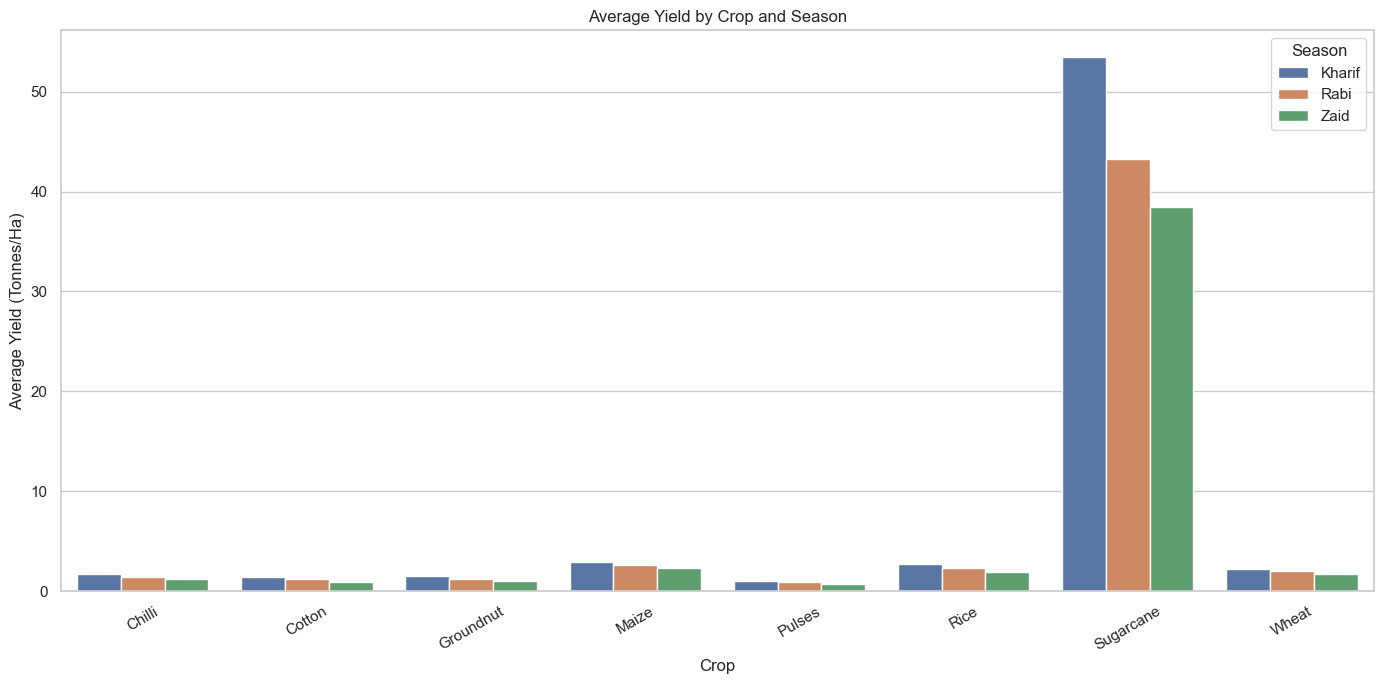

Interpretation: Crop performance differs across seasons. These results can help identify crop-season combinations that deserve further investigation.


In [101]:
# Student Analysis 3
# Question: Which crop performs best within each season based on average yield?

student_crop_season = (
    df.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"]
      .mean()
      .reset_index()
)

top_crop_each_season = (
    student_crop_season.loc[
        student_crop_season.groupby("Season")["Yield_Tonnes_Ha"].idxmax()
    ]
    .sort_values("Season")
    .round(2)
)

display(top_crop_each_season)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=student_crop_season,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season",
    errorbar=None
)
plt.title("Average Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Interpretation: Crop performance differs across seasons. These results can help identify crop-season combinations that deserve further investigation.")


## 15. Key Insights

Write **at least 8 meaningful insights** from the analysis.

For each insight, follow this structure:

1. **Observation** – What did you observe?
2. **Evidence** – Which analysis supports it?
3. **Interpretation** – What does the evidence indicate?
4. **Limitation** – What should not be assumed from the finding?

Avoid statements that claim causation when the analysis only shows association.


In [102]:
# Evidence-based key insights
# The values below are generated from the cleaned dataset so that the written insights
# remain consistent with the actual analysis.

season_summary = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Median_Profit=("Profit_INR", "median"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

best_yield_season = season_summary["Average_Yield"].idxmax()
best_profit_season = season_summary["Average_Profit"].idxmax()
best_water_efficiency_season = season_summary["Average_Water_Efficiency"].idxmax()
highest_risk_season = season_summary["Average_Disease_Risk"].idxmax()

positive_profit_rate = (
    df.assign(Profitable=df["Profit_INR"] > 0)
      .groupby("Season")["Profitable"]
      .mean()
      .mul(100)
      .round(1)
)

irrigation_yield = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().round(2)
best_irrigation = irrigation_yield.idxmax()

crop_season = (
    df.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"]
      .mean()
      .reset_index()
)
top_crop = crop_season.loc[
    crop_season.groupby("Season")["Yield_Tonnes_Ha"].idxmax()
].sort_values("Season")

yield_corr = df[
    ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
     "Sunlight_Hours_Day", "Soil_Moisture_pct",
     "Fertilizer_kg_ha", "Pesticide_Litre_ha",
     "Seed_Quality_Score", "Yield_Tonnes_Ha"]
].corr()["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values()

print("KEY INSIGHTS")
print("-" * 80)

for season, row in season_summary.iterrows():
    print(
        f"{season}: average yield = {row['Average_Yield']:.2f} tonnes/ha, "
        f"average profit = ₹{row['Average_Profit']:,.0f}, "
        f"water efficiency = {row['Average_Water_Efficiency']:.2f} t/1000m³, "
        f"disease/pest risk = {row['Average_Disease_Risk']:.2f}%."
    )

print(
    f"1. {best_yield_season} has the highest average yield "
    f"({season_summary.loc[best_yield_season, 'Average_Yield']:.2f} tonnes/ha)."
)

print(
    f"2. {best_profit_season} has the highest average profit "
    f"(₹{season_summary.loc[best_profit_season, 'Average_Profit']:,.0f})."
)

print(
    f"3. {best_water_efficiency_season} has the highest average water efficiency "
    f"({season_summary.loc[best_water_efficiency_season, 'Average_Water_Efficiency']:.2f} t/1000m³)."
)

print(
    f"4. {highest_risk_season} has the highest average disease/pest risk "
    f"({season_summary.loc[highest_risk_season, 'Average_Disease_Risk']:.2f}%)."
)

print(
    f"5. The share of profitable farms varies by season: "
    + ", ".join([f"{s} {v:.1f}%" for s, v in positive_profit_rate.items()])
    + "."
)

print(
    f"6. Among irrigation methods, {best_irrigation} has the highest observed "
    f"average yield ({irrigation_yield.loc[best_irrigation]:.2f} tonnes/ha)."
)

print("7. Highest-yielding crop within each season:")
for _, row in top_crop.iterrows():
    print(
        f"   {row['Season']}: {row['Crop']} "
        f"({row['Yield_Tonnes_Ha']:.2f} tonnes/ha)"
    )

print(
    f"8. The strongest simple correlation with yield among the selected "
    f"environmental/input variables is {yield_corr.index[-1]} "
    f"(r = {yield_corr.iloc[-1]:.3f})."
)

print("\nImportant limitation: these are observational relationships. "
      "They should not be interpreted as proof that one factor causes another.")


KEY INSIGHTS
--------------------------------------------------------------------------------
Kharif: average yield = 5.63 tonnes/ha, average profit = ₹178,915, water efficiency = 5.89 t/1000m³, disease/pest risk = 54.47%.
Rabi: average yield = 5.04 tonnes/ha, average profit = ₹87,689, water efficiency = 5.19 t/1000m³, disease/pest risk = 40.48%.
Zaid: average yield = 4.64 tonnes/ha, average profit = ₹-24,805, water efficiency = 4.41 t/1000m³, disease/pest risk = 38.22%.
1. Kharif has the highest average yield (5.63 tonnes/ha).
2. Kharif has the highest average profit (₹178,915).
3. Kharif has the highest average water efficiency (5.89 t/1000m³).
4. Kharif has the highest average disease/pest risk (54.47%).
5. The share of profitable farms varies by season: Kharif 57.8%, Rabi 48.9%, Zaid 35.5%.
6. Among irrigation methods, Drip has the highest observed average yield (6.58 tonnes/ha).
7. Highest-yielding crop within each season:
   Kharif: Sugarcane (53.46 tonnes/ha)
   Rabi: Sugarcane 

## 16. Recommendations

Based on the observed results:

1. **Use season-specific planning:** Agricultural planning should account for the differences observed in yield, profitability, water efficiency and disease/pest risk across Kharif, Rabi and Zaid.

2. **Prioritize efficient irrigation for further investigation:** Irrigation methods showed different average yields. The method with the highest observed yield can be studied further while also considering water consumption and local conditions.

3. **Monitor high-risk seasons:** The season with the highest observed disease/pest risk should receive closer monitoring and preventive planning.

4. **Evaluate crop-season combinations:** Crop performance differs across seasons. Farmers and planners can investigate the strongest crop-season combinations rather than treating all crops as equally suitable in every season.

5. **Focus on profitability, not yield alone:** A higher yield does not automatically imply higher profit because production costs and market prices also affect economic outcomes.

6. **Improve water-use planning:** Seasonal differences in water efficiency suggest that irrigation and water allocation should be evaluated together with crop and seasonal conditions.

7. **Use statistical evidence when making comparisons:** Seasonal differences should be interpreted together with statistical tests and not only from visual differences in charts.

**Limitation:** These recommendations are based on observational data. Additional field-level information and controlled studies would be required before making causal claims or applying a recommendation universally.


## 17. Conclusion

The analysis examined 4,000 farm-level agricultural records across the Kharif, Rabi and Zaid seasons. The dataset contains environmental conditions, soil characteristics, farming inputs, irrigation methods, crop performance, water usage, economic outcomes and disease/pest risk.

The seasonal analysis shows that agricultural performance is not identical across seasons. Kharif records have the highest observed average yield, average profit and water efficiency in this dataset, while disease/pest risk is also highest in Kharif. The proportion of profitable farms also varies across seasons.

The analysis further shows differences among irrigation methods and crop-season combinations. Statistical testing provides additional evidence that the mean profit differs significantly across seasons, while the seasonal difference in mean yield should be interpreted according to the ANOVA result generated in the notebook.

Overall, the project demonstrates how data analytics can be used to compare seasonal agricultural performance and identify patterns in productivity, resource efficiency, risk and profitability.

### Limitations

- The dataset is observational, so associations should not be interpreted as causal relationships.
- Seasonal comparisons may also reflect differences in crop mix, location, farm size and farming practices.
- Median imputation was used for missing numerical values, which can reduce the natural variation in those variables.
- Further analysis with additional years, weather history, market conditions and controlled field studies could provide stronger evidence.

### Final takeaway

Seasonal agricultural planning should consider multiple dimensions—yield, profitability, water efficiency, environmental conditions and disease/pest risk—rather than relying on a single performance measure.


## 18. Project Checklist

Before submission, confirm that the notebook has been run from top to bottom and includes:

- [x] Dataset loading and verification
- [x] Dataset shape and structure examined
- [x] Top 5 and bottom 5 records examined
- [x] Random sample examined
- [x] Column names and data types examined
- [x] Numerical and categorical summaries
- [x] Missing values identified and treated
- [x] Duplicate records checked
- [x] Numerical/categorical variables reviewed
- [x] Descriptive statistics performed
- [x] Season-wise statistics performed
- [x] Univariate analysis completed
- [x] Outliers investigated
- [x] Bivariate analysis completed
- [x] Multivariate analysis completed
- [x] Correlation analysis completed
- [x] Seasonal comparisons performed
- [x] Statistical significance testing performed
- [x] Three student-designed analyses completed
- [x] At least eight evidence-based insights generated
- [x] Recommendations provided
- [x] Limitations discussed
- [x] Final conclusion provided

**Final step before submission:** Restart the kernel and run all cells from top to bottom in VS Code. Confirm that there are no errors and that all charts/tables are displayed correctly.
